In [2]:
import numpy as np
import rasterio
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [3]:
# importing library to convert notebook to web page
import streamlit as st

connecting to API
searching for recent landsat items
Found best match: LC08_L2SP_042034_20260609_02_T1 (Date: 2026-06-09T18:32:48.232674Z)
streaming and cropping Band 4 (Red)
streaming and cropping Band 5 (NIR)
calculating ndvi array
NDVI processing complete. Result shape: (104, 104)
Found Data

Sample NDVI 5x5 grid slice:
[[0.048 0.068 0.094 0.114 0.151]
 [0.072 0.076 0.113 0.132 0.196]
 [0.118 0.08  0.101 0.136 0.257]
 [0.138 0.079 0.064 0.146 0.311]
 [0.126 0.063 0.099 0.253 0.327]]
(104, 104)


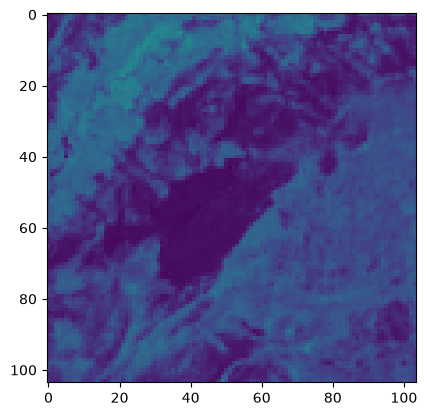

In [4]:
#importing other notebook
import importnb
with importnb.Notebook():
    from ndvi import get_landsat_ndvi_matrix

The below function `adv_synthetic_ndvi` and `simple_synthetic_ndvi` are temporary functions. Once the google earth engine is accessible by this project, it will be only used for short tests.

In [5]:
def adv_synthetic_ndvi(shape = (300,300), seed = -1):
  """
  This function creates a randomly generated numpy array to simulate ndvi data
  from GEE, can pass a set size for the array and a set seed if it is needed
  """

  # only use seed if one was provided
  if (seed != -1):
    np.random.seed(seed)

  # create the first layer of noise
  noise = np.random.uniform(0,1, shape)


  # using a gaussian blur to smooth the noise for a more natural array
  smoothed = gaussian_filter(noise, sigma = 5)

  # normalizing back to farm and surrounding levels
  ndvi = 0.15 + (smoothed - smoothed.min()) / (smoothed.max() - \
    smoothed.min()) * 0.70

In [6]:
def simple_synthetic_ndvi(shape=(100, 100)):
    """
    even more simple proof of concept of `adv_synthetic_ndvi`
    """
    # create empty numpy array
    ndvi = np.zeros(shape, dtype=np.float32)+.1

    # locations of farms (high ndvi)
    ndvi[5:45, 5:45]   = 0.8
    ndvi[5:45, 55:95]  = 0.8
    ndvi[55:95, 5:45]  = 0.8
    ndvi[55:95, 55:95] = 0.8

    return ndvi

The below function `conv_kernal` is meant to create a different covolutional matrix for the sir model, one infected square can, by default, spread up to 3 grids away, with % decreasing in accordance to inverse square law. <br>
Currently this kernel is using aribtrary values. Before real life application, ideally each disease this cnn will be trained to detect has a dedicated CK for it and diseases with similar spreading capabilities. Future improvements could include wind or water changing the spread likelihood.

In [7]:
def conv_kernal(radius = 3):
  """
  creates a ck with size 2*radius + 1
  this allows infections to spread up to 3 tiles away
  """
  size = 2 * radius + 1
  kernel = np.zeros((size,size))
  for y in range(size):
    for x in range(size):
      if x == radius and y == radius:
        kernel[y,x] = 0 # plants cannot reinfect themselves
        continue

In [8]:
def generate_wind_kernel(radius = 2, sigma=1.0, wind_x=0.0, wind_y=0.0):
    """
    convolutional matrix but with a wind vector

    inputs
    radius - distance a disease can spread
    sigma - spread of the disease through the wind
    wind_x - horizontal component of wind (0 blows east (right))
    wind_y - vertical component of wind (0 blows north (up))

    returns
    conv_matrix
    """

    # radius of 2 = 5x5 conv matrix
    size = 2*radius + 1


    # Create a coordinate grid centered at (0,0)
    # creating the array
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)

    # calculating the probabilities with the wind
    kernel = np.exp(-((xx - wind_x)**2 + (yy - wind_y)**2) / (2 * sigma**2))

    # return and normalize
    return kernel / np.sum(kernel)


Below is the final simulation code, what is changed above should not alter the core structure of the simulation step function.

In [9]:
def sir_spatial_step(S, I, R, ndvi, conv_matrix, beta, gamma, dt=1.0):
    """
    single step in the simulation

    inputs

    S, I, R - numpy arrays of same shape
    ndvi - array of plant begetation density(influences spreadability)
    conv_matrix convulutional matrix for optimized disease spread
    beta - transmission rate
    gamma - Recovery/removal rate (not able to be reinfected)
    dt - time step size (default 1)

    returns
    S_next, I_next, R_next - next step of the simulation
    """
    # calculating base chance for tiles to be infected
    # same - do not change the output shape
    # fill - assumes nearby vegetation is not undergoing the same disease yet
    infected_pressure = convolve2d(I, conv_matrix, mode='same', boundary='fill')


    # adjusting transmission with beta, ndvi, and time using susceptibile array
    new_infections = beta * S * ndvi * infected_pressure * dt

    # calculating recoveries with gamma and dt
    new_recoveries = gamma * I * dt

    # making sure not to infect or recover more than what is available in a cell
    # ensures further calculations do not go negative
    new_infections = np.minimum(new_infections, S)
    new_recoveries = np.minimum(new_recoveries, I)

    # saving the new SIR numpy arrays
    S_next = S - new_infections
    I_next = I + new_infections - new_recoveries
    R_next = R + new_recoveries

    # realign values to our ranges
    S_next = np.clip(S_next, 0.0, 1.0)
    I_next = np.clip(I_next, 0.0, 1.0)
    R_next = np.clip(R_next, 0.0, 1.0)

    return S_next, I_next, R_next

In [10]:
def start_SIR_random(input_array):
    """
    1) Selects a random element in the input array and changes its value to 1.
    2) Creates two additional arrays of zeros with the exact same shape.
    3) Returns all three arrays.

    Parameters:
    input_array (list or np.ndarray): The source array to modify.

    Returns:
    tuple: (modified_original_array, zero_array_1, zero_array_2)
    """
    # Convert input to a numpy array just to easily extract its shape safely
    input_np = np.asarray(input_array)

    # 1. Create the first new array of zeros and set a random element to 1
    I = np.zeros_like(input_np)
    rando = I.shape

    # Pick a random flat index and map it back to the multi-dimensional shape
    I[np.random.randint(0,rando[0]-1)][np.random.randint(0,rando[1] -1)] = 1

    # 2. Create 2 additional arrays of zeros with the same shape
    S = np.zeros_like(input_np) + 1 - I
    R = np.zeros_like(input_np)

    # 3. Return all three newly created arrays
    return S, I, R

Start simulation code.<br>
potential future improvements<br>
`CK` represents a strong wind in a compass direction<br>
Multiple random small diseases that start up and die<br>
saving each step to a file and labeling the type of disease<br>
using available information to estimate beta and gamma for real diseases

In [11]:
def random_simulation(shape = (100,100), timesteps = 100, beta = -1, gamma = -1):

  """
  Function to bulk run random simulations
  #TODO look into proper distrubtion of beta and gamma values for plant diseases
  currently incomplete

  inputs

  shape - size of the simulation
  timesteps - number of timesteps for the simulation before completion
  beta - infection rate (0 = cannot infect 1 = highly infectious)
  gamma - recovery/death rate (0 = cannot recover 1 = all recover instantly)

  returns
  nothing (will save each simulation step to file later)

  """

  if (beta == -1):
    #TODO random beta
    beta = .3
  if (gamma == -1):
    #TODO random gamma
    gamma = .05


  beta = 0.3   # infection rate (0 = cannot infect 1 = highly infectious)
  gamma = 0.05 # recovery/death rate
  # initialize SIR #TODO

  for t in range(timesteps):
      S, I, R = sir_spatial_step(S, I, R, ndvi, conv_matrix, beta, gamma)

      # save history of simulation to train the cnn currently every 10 steps
      # while bugs are still being testind
      if t % 10 == 0:
          print(f"Step {t}: Total Infected Fraction = {np.mean(I):.4f}")

In [12]:
# init ndvi data
target_lat = 37.498056
target_lon = -120.812583

try:
  ndvi = get_landsat_ndvi_matrix(target_lat, target_lon, half_side_meters=1500)
  print("Found Data")
except Exception as e:
  print(f"An error occurred: {e}")


connecting to API
searching for recent landsat items
Found best match: LC08_L2SP_043034_20260531_02_T1 (Date: 2026-05-31T18:38:58.623369Z)
streaming and cropping Band 4 (Red)
streaming and cropping Band 5 (NIR)
calculating ndvi array
NDVI processing complete. Result shape: (104, 103)
Found Data


Creating function to adjust numpy array to unsigned integer 8 bit for improved storage.

In [ ]:
def convertToUInt(arr):
    return np.round(arr *255).astype

Creating function to randomly choose beta and gamma

In [ ]:
import random
import math



def randomBG(choice = 'none'):
    """
    Function to randomly choose beta and gamma

    inputs

    choice (optional) - override the random selection of disease spreadability
        TODO(?) - maybe choose specific values of beta or gamma?
        might defeat the purpose of this function though

    returns

    beta - variable for the spread rate of the disease
    gamma - rate the infected individuals are removed from the infected category

    """
    # Tiered sampling to get an even mix of slow, medium, and fast diseases
    if choice in ['slow', 'medium', 'fast']:
        disease_type = choice
    else:
        disease_type = random.choice(['slow', 'medium', 'fast'])
    while True:
        

        if disease_type == 'slow':
            beta = random.uniform(0.01, 0.08)
            gamma = random.uniform(0.005, 0.04)
        elif disease_type == 'medium':
            beta = random.uniform(0.08, 0.20)
            gamma = random.uniform(0.04, 0.10)
        else: # fast
            beta = random.uniform(0.20, 0.60)
            gamma = random.uniform(0.10, 0.30)

        # ensure randomly chosen beta and gamma are viable outbreak values
        if beta / gamma > 1.0:
            return beta, gamma

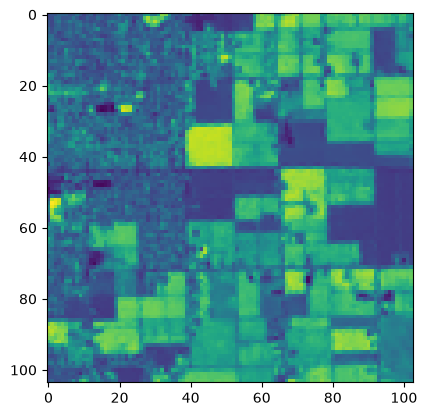

In [17]:

plt.imshow(ndvi, vmin=0.0, origin='upper')

beta = .3
gamma = .008
conv_matrix = generate_wind_kernel(radius = 5,sigma = 3, wind_x = 4, wind_y = 2)
S, I, R= start_SIR_random(ndvi)
timetotal = 0

#plt.imshow(conv_matrix, vmin=0.0, origin='upper')


Step 501: Total Infected = 1075
Step 511: Total Infected = 1082
Step 521: Total Infected = 1087
Step 531: Total Infected = 1091
Step 541: Total Infected = 1092
Step 551: Total Infected = 1092
Step 561: Total Infected = 1090
Step 571: Total Infected = 1085
Step 581: Total Infected = 1079
Step 591: Total Infected = 1070


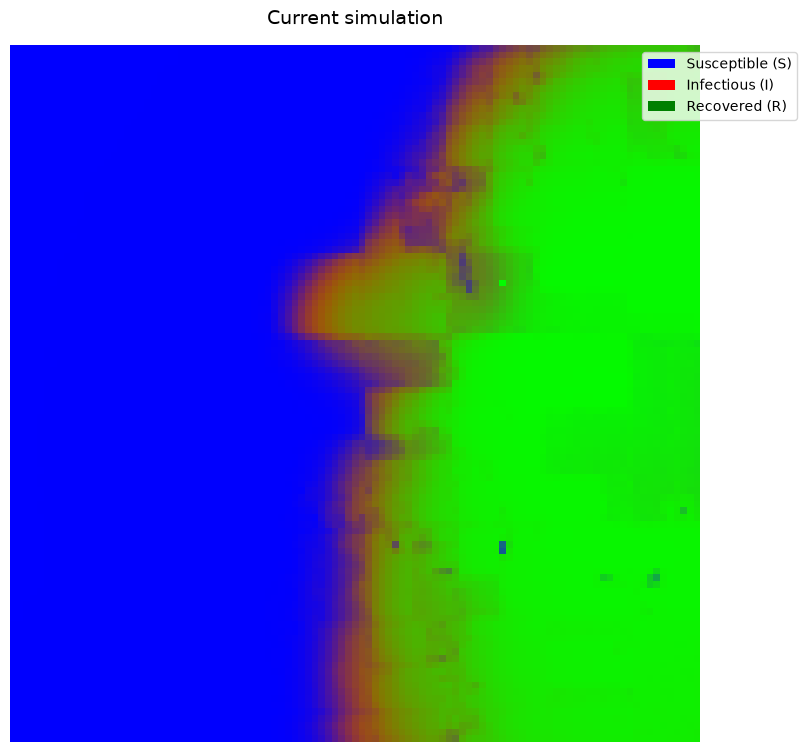

In [23]:
timesteps = 100

for t in range(timesteps):
  timetotal += 1
  S, I, R = sir_spatial_step(S, I, R, ndvi, conv_matrix, beta, gamma)

  # save history of simulation to train the cnn currently every 10 steps
  # while bugs are still being testind
  if t % 10 == 0:
    print(f"Step {timetotal}: Total Infected = {np.sum(I):.0f}")
    # plt.plot(S, label='Susceptible', color='#1f77b4', linewidth=2.5) # Blue
    # plt.plot(I, label='Infected', color='#d62728', linewidth=2.5)    # Red
    # plt.plot(R, label='Recovered', color='#2ca02c', linewidth=2.5)   # Green
rgb_grid = np.stack([I, R, S], axis=-1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_grid, origin='upper')

plt.title("Current simulation", fontsize=14, pad=15)
plt.axis('off')

# Custom legend matching the RGB mapping
legend_elements = [
    Patch(facecolor='blue', label='Susceptible (S)'),
    Patch(facecolor='red', label='Infectious (I)'),
    Patch(facecolor='green', label='Recovered (R)')
]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()